### **Autor:** David Roca Tauste

---
---
# **📌ACTIVIDAD 4: CLASIFICAR OBRAS DE ARTE**
---
---

## ENTREGA 7:
### a) Fotografías subidas a la carpeta compartida:
Ya están subidas.

### b) Fichero csv con los datos de las fotografías transformado y código que las transforma.
Se encuentra junto con este archivo.

## DEFINIR DATASET

In [25]:
import numpy as np
import pandas as pd
import re
import cv2
import os

carpeta = "./Cuadros"
archivo_salida = "davroctau_cuadros.csv"

# Recorrer todas las imágenes en la carpeta
datos_procesados = []
#patron = r"^\d+.*\_.*(jpg|png|jfif)$"
patron = r"^[A-Za-z0-9]+-[A-Za-z0-9]+-\d+\.(jpg|png)$"


for nombre_archivo in os.listdir(carpeta):
    print(nombre_archivo)

    ruta_completa = os.path.join(carpeta, nombre_archivo)
    if not re.match(
        patron, nombre_archivo
    ):  # Si el fichero no es imagen con dato numérico antes de _
        continue
    pintor = nombre_archivo.split("-")[0]

    # Leer la imagen en escala de grises, escalarla, guardar la procesada
    imagen = cv2.imread(ruta_completa, cv2.IMREAD_GRAYSCALE)
    if imagen is None:
        print(f"No se pudo leer: {nombre_archivo}")
        continue
    imagen_escalada = cv2.resize(
        imagen, (592, 612), interpolation=cv2.INTER_AREA
    )  # Escala a 92x112
    cv2.imwrite(os.path.join(carpeta, "img_" + nombre_archivo), imagen_escalada)
    imagen_normalizada = (imagen_escalada / 255.0).astype(
        np.float32
    )  # Normalizar a [0,1]
    datos_procesados.append(
        {"pintor": pintor, "imagen": imagen_normalizada}
    )  # Añadir datos a datos_procesados

# Convertir datos_procesados a DataFrame y guardar como csv
df = pd.DataFrame(
    {
        "pintor": [d["pintor"] for d in datos_procesados],
        "imagen": [",".join(map(str, np.ravel(d["imagen"]))) for d in datos_procesados],
    }
)

df.to_csv(archivo_salida, index=False)
print(f"Se guardaron {len(datos_procesados)} imágenes procesadas en '{archivo_salida}'")

Cezzane-davroctau-01.jpg
Dali-davroctau-02.jpg
Gaugin-davroctau-03.jpg
Goya-davroctau-04.jpg
img_Cezzane-davroctau-01.jpg
img_Dali-davroctau-02.jpg
img_Gaugin-davroctau-03.jpg
img_Goya-davroctau-04.jpg
img_Kandinsky-davroctau-05.jpg
img_Miro-davroctau-06.jpg
img_Monet-davroctau-07.jpg
img_Picasso-davroctau-08.jpg
img_Rubens-davroctau-10.jpg
img_Sorolla-davroctau-11.jpg
img_Tiziano-davroctau-12.jpg
img_Velazquez-davroctau-14.jpg
Kandinsky-davroctau-05.jpg
Miro-davroctau-06.jpg
Monet-davroctau-07.jpg
Picasso-davroctau-08.jpg
Renoir-davroctau-09.jfif
Rubens-davroctau-10.jpg
Sorolla-davroctau-11.jpg
Tiziano-davroctau-12.jpg
Vangohg-davroctau-13.jfif
Velazquez-davroctau-14.jpg
Se guardaron 12 imágenes procesadas en 'davroctau_cuadros.csv'


In [26]:
df = pd.read_csv(archivo_salida)

# Convertir la imagen de string a numpy array
df["imagen"] = df["imagen"].apply(lambda x: np.array(list(map(float, x.split(",")))).reshape(612, 592))

# Imprimir datos de la primera cara
print(f"Pintor: {df.iloc[0]['pintor']} Imagen: {df.iloc[0]['imagen']}")
pixel_array = (df.iloc[0]["imagen"] * 255).astype(np.uint8)
#cv2.imshow("Pintor:", pixel_array)
cv2.waitKey(0)
cv2.destroyAllWindows()

Pintor: Cezzane Imagen: [[0.11764706 0.12941177 0.10196079 ... 0.18039216 0.1764706  0.19607843]
 [0.11764706 0.12941177 0.10196079 ... 0.18039216 0.1764706  0.19607843]
 [0.12941177 0.1254902  0.11764706 ... 0.16862746 0.16862746 0.20784314]
 ...
 [0.16078432 0.22745098 0.23529412 ... 0.5764706  0.5686275  0.5529412 ]
 [0.2        0.25882354 0.23137255 ... 0.6156863  0.5921569  0.53333336]
 [0.2        0.25882354 0.23137255 ... 0.6156863  0.5921569  0.53333336]]


In [27]:
df.head()

,pintor,imagen
0,Cezzane,"[[0.11764706, 0.12941177, 0.101960786, 0.11372..."
1,Dali,"[[0.38039216, 0.38039216, 0.38039216, 0.392156..."
2,Gaugin,"[[0.92941177, 0.92941177, 0.92941177, 0.929411..."
3,Goya,"[[0.10980392, 0.10980392, 0.11372549, 0.117647..."
4,Kandinsky,"[[0.65882355, 0.6431373, 0.6313726, 0.64705884..."


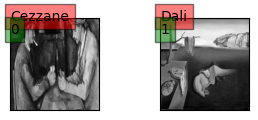

In [28]:
import matplotlib.pyplot as plt

def print_imagenes(imgs, targets, desde, hasta):
    # configuramos el tamaño de las imágenes por pulgadas
    fig = plt.figure(figsize=(30, 24))
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

    for i in range(desde, hasta):
        # graficamos las imágenes en una matriz de 25x20
        p = fig.add_subplot(25, 20, i + 1, xticks=[], yticks=[])
        p.imshow(imgs[i], cmap="gray")

        # etiquetar imágenes con target e indice
        p.text(0, 14, str(targets[i]), bbox=dict(facecolor="red", alpha=0.5))
        p.text(0, 100, str(i), bbox=dict(facecolor="green", alpha=0.5))
    plt.show()

print_imagenes(df.iloc[:, :]["imagen"], df.iloc[:, :]["pintor"], 0, 2)

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [30]:
# Preparar características del dataframe
df_pixels = df["imagen"].apply(lambda img: img.flatten())  # Aplana cada imagen
df_pixels = pd.DataFrame(df_pixels.tolist())  # Expandir en columnas
df_final = pd.concat([df["pintor"], df_pixels], axis=1)  # Unir con la edad

le = LabelEncoder()
df['pintor'] = le.fit_transform(df['pintor'])

In [31]:
y = df["pintor"]
X = df_final.drop(columns=["pintor"])  # Características (píxeles)

df.head()

,pintor,imagen
0,0,"[[0.11764706, 0.12941177, 0.101960786, 0.11372..."
1,1,"[[0.38039216, 0.38039216, 0.38039216, 0.392156..."
2,2,"[[0.92941177, 0.92941177, 0.92941177, 0.929411..."
3,3,"[[0.10980392, 0.10980392, 0.11372549, 0.117647..."
4,4,"[[0.65882355, 0.6431373, 0.6313726, 0.64705884..."


In [32]:
def resumen_resultado(
    y_train, y_train_predicho, y_test, y_test_predicho, nombre_modelo="modelo"
):
    rmse_train = mean_squared_error(y_train, y_train_predicho) ** 0.5
    rmse_test = mean_squared_error(y_test, y_test_predicho) ** 0.5
    print(f"RMSE en train de {nombre_modelo}: {rmse_train:.6f}")
    print(f"RMSE en test de {nombre_modelo}: {rmse_test:.6f}")
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_test, color="red", label="Valor real")
    plt.scatter(y_test, y_test_predicho, color="blue", label="Valor predicho")
    plt.xlabel("peligrosidad")
    plt.ylabel("peligrosidad predicha")
    plt.axvline()
    plt.axhline()
    plt.title(f"Valor-predicción en Test ({nombre_modelo})")
    plt.legend()

    plt.subplot(1, 2, 2)
    bar_width = 0.35
    bars1 = plt.bar(
        2 - bar_width / 2,
        rmse_train,
        width=bar_width,
        label="RMSE Train",
        color="royalblue",
    )
    bars2 = plt.bar(
        2 + bar_width / 2, rmse_test, width=bar_width, label="RMSE Test", color="tomato"
    )

    # Anotar valores encima de las barras
    for bars in [bars1, bars2]:
        for bar in bars:
            yval = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                yval,
                f"{yval:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    plt.ylabel("RMSE")
    plt.title("RMSE en train y test")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

## IMPLEMENTAR CLASIFICADORES

### c) División de los datos en train y test dejando el 80% de datos para train e intentando no desbalancear los datos y con tu propia semilla aleatoria.

In [33]:
print(y)

0      0
1      1
2      2
3      3
4      4
5      5
6      6
7      7
8      8
9      9
10    10
11    11
Name: pintor, dtype: int64


In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor
)

semilla = 546
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=semilla)

# Si hubiese más de un cuadro por pintor
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=semilla, stratify=y)

escalador = StandardScaler()
X_train = escalador.fit_transform(X_train)
X_test = escalador.transform(X_test)

## MEDIR DESEMPEÑO

### d) Realizar entrenamiento de los 4 clasificadores.
Prueba al menos a entrenar 2 clasificadores:
- El primero: SVC ó Árbol ó RandomForest.
- El segundo: método ensemble: Boost/Bagging.

### e) Mostrar informe de clasificación.

### f) Mostrar matriz de confusión.

### g) Mostrar gráfico comparativo.

RMSE en train de RandomForestRegressor: 2.898497
RMSE en test de RandomForestRegressor: 4.911041


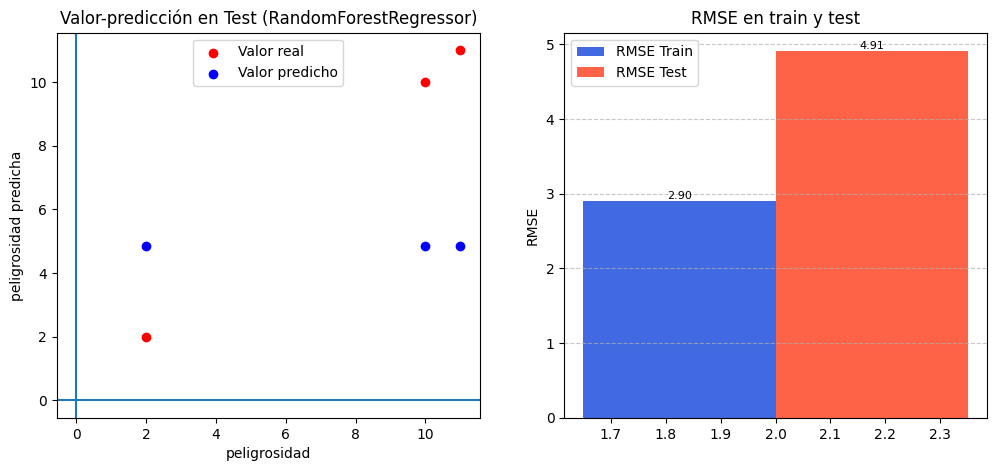

In [35]:
# RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=semilla)
rf.fit(X_train, y_train)
resumen_resultado(y_train, rf.predict(X_train), y_test, rf.predict(X_test), "RandomForestRegressor")

RMSE en train de AdaBoostRegressor: 0.000000
RMSE en test de AdaBoostRegressor: 5.916080


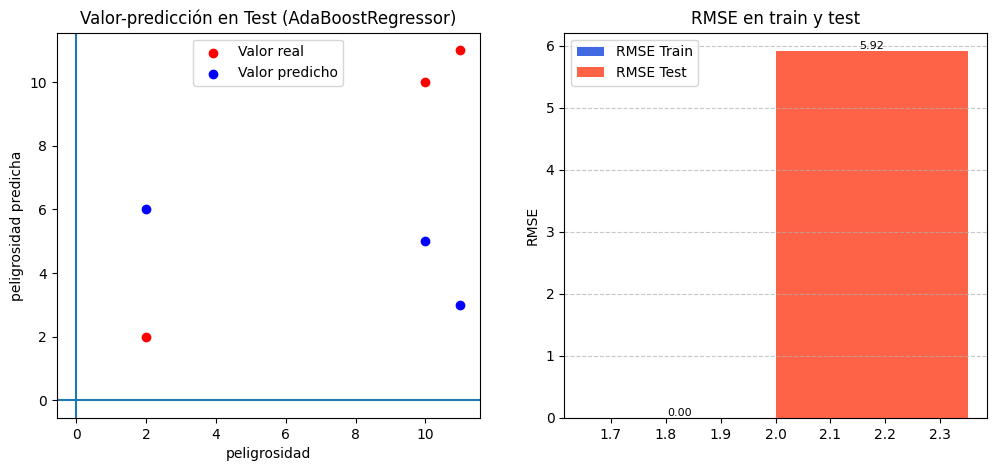

In [36]:
# AdaBoostRegressor
ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.5, random_state=semilla)
ada.fit(X_train, y_train)
resumen_resultado(y_train, ada.predict(X_train), y_test, ada.predict(X_test), "AdaBoostRegressor")

## MEJORAR ALGUNO AJUSTANDO HIPERPARÁMETROS

### h) Mejora del desempeño de alguno cambiando sus hiperparámetros.

In [37]:
from sklearn.model_selection import GridSearchCV

rf_hiperparametros = RandomForestRegressor(random_state=semilla)

parametros = {
    "n_estimators": [10, 20],
    "max_depth": [2, 5],
    "min_samples_leaf": [1, 3],
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=parametros,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros encontrados:
{'max_depth': 2, 'min_samples_leaf': 1, 'n_estimators': 10}


In [39]:
mejores_parametros = grid_search.best_params_

rf_hiperparametros = RandomForestRegressor(
    random_state=semilla,
    **mejores_parametros
)

rf_hiperparametros.fit(X_train, y_train)

RandomForestRegressor(max_depth=2, n_estimators=10, random_state=546)

RMSE en train de RandomForestRegressor: 1.617374
RMSE en test de RandomForestRegressor: 4.960272


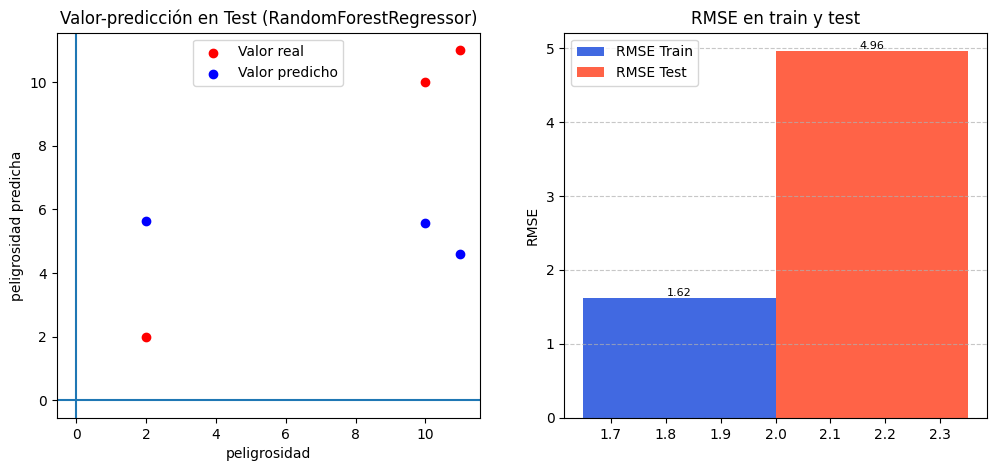

In [40]:
resumen_resultado(y_train, rf_hiperparametros.predict(X_train), y_test, rf_hiperparametros.predict(X_test), "RandomForestRegressor")